In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

project_path = "./examples/elastic/Iso-elastic-Marmousi2-shotTop-recTop/data"

init_vp=np.load(os.path.join(project_path ,"model/init_model.npz"))["vp"]
init_vs=np.load(os.path.join(project_path ,"model/init_model.npz"))["vs"]
init_rho=np.load(os.path.join(project_path,"model/init_model.npz"))["rho"]
true_vp=np.load(os.path.join(project_path ,"model/true_model.npz"))["vp"]
true_vs=np.load(os.path.join(project_path ,"model/true_model.npz"))["vs"]
true_rho=np.load(os.path.join(project_path,"model/true_model.npz"))["rho"]

def load_data(regular):
    iter_vp   = np.load(os.path.join(project_path,f"inversion_{regular}/iter_vp.npz"))["data"][:]
    iter_vs   = np.load(os.path.join(project_path,f"inversion_{regular}/iter_vs.npz"))["data"][:]
    iter_rho  = np.load(os.path.join(project_path,f"inversion_{regular}/iter_rho.npz"))["data"][:]
    iter_loss = np.load(os.path.join(project_path,f"inversion_{regular}/iter_loss.npz"))["data"][:]
    return iter_loss,iter_vp,iter_vs,iter_rho

iter_loss_tikhonov1,iter_vp_tikhonov1,iter_vs_tikhonov1,iter_rho_tikhonov1 = load_data("tikhonov1")
iter_loss_tikhonov2,iter_vp_tikhonov2,iter_vs_tikhonov2,iter_rho_tikhonov2 = load_data("tikhonov2")
iter_loss_tv1,iter_vp_tv1,iter_vs_tv1,iter_rho_tv1 = load_data("tv1")
iter_loss_tv2,iter_vp_tv2,iter_vs_tv2,iter_rho_tv2 = load_data("tv2")

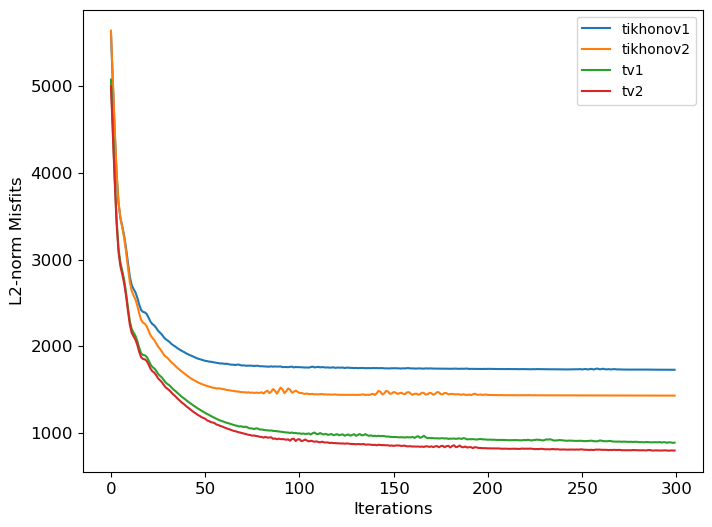

In [2]:
# plot the misfit
plt.figure(figsize=(8,6))
plt.plot(iter_loss_tikhonov1,label="tikhonov1")
plt.plot(iter_loss_tikhonov2,label="tikhonov2")
plt.plot(iter_loss_tv1,label="tv1")
plt.plot(iter_loss_tv2,label="tv2")
plt.legend()
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("L2-norm Misfits", fontsize=12)
plt.tick_params(labelsize=12)
plt.show()

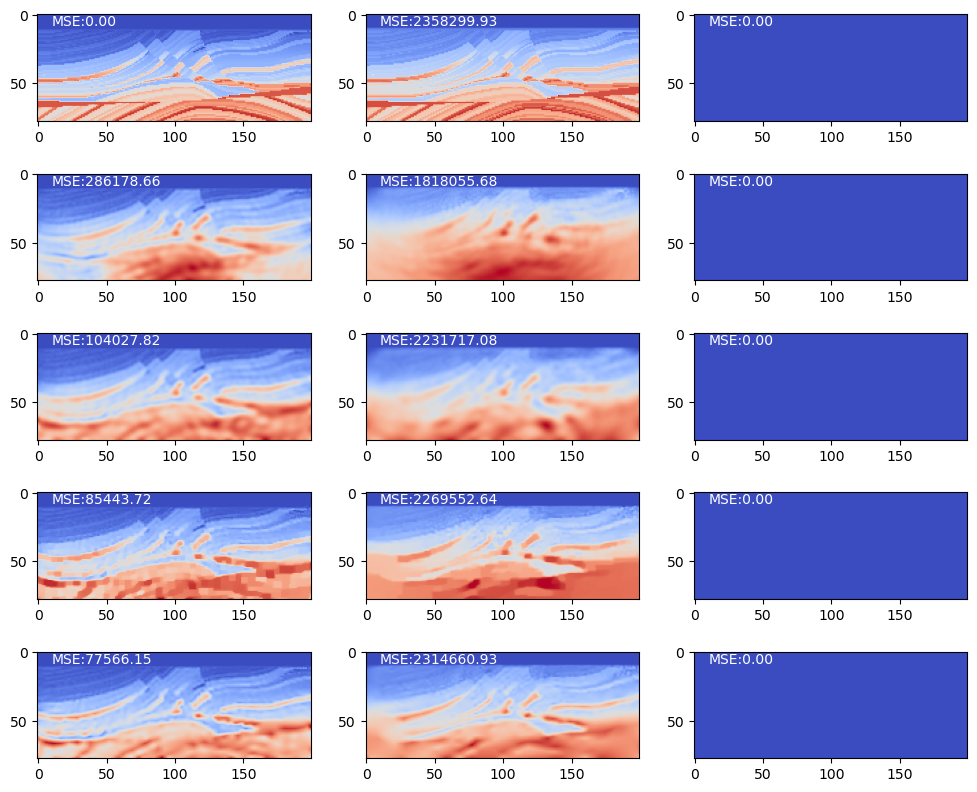

In [3]:
from ADFWI.utils.assessment_metric import *
# plot the initial model and inverted resutls
def plot_part(ax,row,vp,vs,rho,vmin=None,vmax=None):
    ax[row][0].imshow(vp    ,cmap='coolwarm')
    ax[row][1].imshow(vs    ,cmap='coolwarm')
    ax[row][2].imshow(rho   ,cmap='coolwarm')
    ax[row][0].text(10,8,"MSE:{:.2f}".format(MSE(vp[12:],true_vp[12:])),c='w')
    ax[row][1].text(10,8,"MSE:{:.2f}".format(MSE(vp[12:],true_vs[12:])),c='w')
    ax[row][2].text(10,8,"MSE:{:.2f}".format(MSE(rho[12:],true_rho[12:])),c='w')
    return

fig,axs = plt.subplots(5,3,figsize=(12,10))
plot_part(axs,0,true_vp,true_vs,true_rho)
plot_part(axs,1,iter_vp_tikhonov1[-1],iter_vs_tikhonov1[-1],iter_rho_tikhonov1[-1])
plot_part(axs,2,iter_vp_tikhonov2[100],iter_vs_tikhonov2[100],iter_rho_tikhonov2[-1])
plot_part(axs,3,iter_vp_tv1[-1],iter_vs_tv1[-1],iter_rho_tv1[-1])
plot_part(axs,4,iter_vp_tv2[-1],iter_vs_tv2[-1],iter_rho_tv2[-1])
plt.show()

## Article Figures

In [4]:
ox,oz  = 0,0
nz,nx  = 78,200
dx,dz  = 45, 45
nt,dt  = 2500, 0.003
nabc   = 50
f0     = 3
free_surface = True

src_z = np.array([2   for i in range(2,nx-2,5)])*dz/1000 
src_x = np.array([i   for i in range(2,nx-2,5)])*dx/1000
rcv_z = np.array([2   for i in range(0,nx,1)])*dz/1000
rcv_x = np.array([j   for j in range(0,nx,1)])*dx/1000


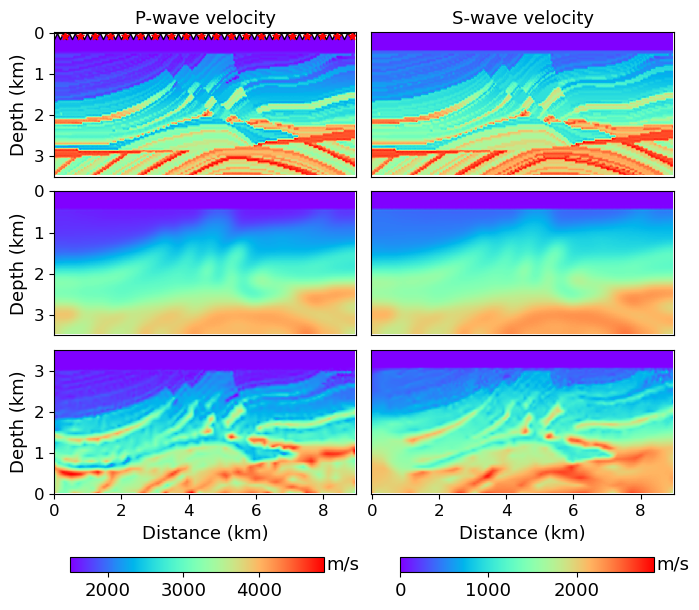

In [5]:
from mpl_toolkits import axes_grid1
fig,axs = plt.subplots(3,2,figsize=(8,6))
# cmap="bwr"
cmap = "rainbow"
z = np.arange(0,nz*dz/1000,dz/1000)
x = np.arange(0,nx*dx/1000,dx/1000)
x_mesh, z_mesh = np.meshgrid(x, z)
x = np.arange(nx*3)*dx/3/1000
z = np.arange(nz*3)*dz/3/1000
x_mesh_new,z_mesh_new = np.meshgrid(x,z)
from scipy.interpolate import griddata
true_vp_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), true_vp.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
true_vs_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), true_vs.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
init_vp_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), init_vp.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
init_vs_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), init_vs.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
inv_vp_new   = griddata((x_mesh.flatten(), z_mesh.flatten()), iter_vp_tv2[-1].flatten(), (x_mesh_new, z_mesh_new), method='cubic')
inv_vs_new   = griddata((x_mesh.flatten(), z_mesh.flatten()), iter_vs_tv2[-1].flatten(), (x_mesh_new, z_mesh_new), method='cubic')

vpmin = true_vp.min()
vpmax = true_vp.max()
vsmin = true_vs.min()
vsmax = true_vs.max()

axs[0][0].pcolormesh(x_mesh_new,z_mesh_new,true_vp_new             ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
axs[0][1].pcolormesh(x_mesh_new,z_mesh_new,true_vs_new             ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")
axs[1][0].pcolormesh(x_mesh_new,z_mesh_new,init_vp_new             ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
axs[1][1].pcolormesh(x_mesh_new,z_mesh_new,init_vs_new             ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")
pcm1 = axs[2][0].pcolormesh(x_mesh_new,z_mesh_new,inv_vp_new[::-1] ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
pcm2 = axs[2][1].pcolormesh(x_mesh_new,z_mesh_new,inv_vs_new[::-1] ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")

axs[0][0].scatter(rcv_x[::4],rcv_z[::4],facecolor="w",edgecolor='k',marker="v",s=20)
axs[0][0].scatter(src_x[1::2],src_z[1::2],c="r",marker="*",s=30)

axs[0][0].invert_yaxis()
axs[0][1].invert_yaxis()
axs[1][0].invert_yaxis()
axs[1][1].invert_yaxis()

axs[0][0].set_xticks([])
axs[0][1].set_xticks([])
axs[0][1].set_yticks([])
axs[1][0].set_xticks([])
axs[1][1].set_xticks([])
axs[1][1].set_yticks([])
axs[2][1].set_yticks([])

axs[0][0].set_ylabel("Depth (km)",fontsize=13)
axs[1][0].set_ylabel("Depth (km)",fontsize=13)
axs[2][0].set_ylabel("Depth (km)",fontsize=13)

axs[2][0].set_xlabel("Distance (km)",fontsize=13)
axs[2][1].set_xlabel("Distance (km)",fontsize=13)

axs[0][0].set_title(r"P-wave velocity",fontsize=13)
axs[0][1].set_title(r"S-wave velocity",fontsize=13)

for i in range(3):
    for j in range(2):
        axs[i][j].tick_params(labelsize=12)

cbar_pad_fraction   = 0.13
cbar_height         = 0.025
cax1 = fig.add_axes([axs[2][0].get_position().x0+0.02,axs[2][0].get_position().y0-cbar_pad_fraction,
                     axs[2][0].get_position().width*0.9,cbar_height])
cbar1 = plt.colorbar(pcm1,cax=cax1,orientation='horizontal')
cbar1.ax.tick_params(labelsize=13)
cbar1.ax.text(1.01, 0.5, "m/s", va='center', ha='left', fontsize=13, transform=cbar1.ax.transAxes)


cax2 = fig.add_axes([axs[2][1].get_position().x0+0.01,axs[2][1].get_position().y0-cbar_pad_fraction,
                     axs[2][1].get_position().width*0.9,cbar_height])
cbar2 = plt.colorbar(pcm2,cax=cax2,orientation='horizontal')
cbar2.ax.tick_params(labelsize=13)
cbar2.ax.text(1.01, 0.5, "m/s", va='center', ha='left', fontsize=13, transform=cbar2.ax.transAxes)

plt.subplots_adjust(hspace=0.1,wspace=0.05)

# plt.savefig(os.path.join(project_path,"Figure4_IsotropicElastic_Model_Test.png"),bbox_inches="tight",dpi=300)
plt.show()

## GIF

In [ ]:
iter_vp,iter_vs,iter_rho = iter_vp_tv2[::5],iter_vs_tv2[::5],iter_rho_tv2[::5]

###########################################
# visualize the inversion results
###########################################
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import os

# Set up the figure for plotting
fig, ax = plt.subplots(3, 1, figsize=(6, 10))  # Increase figsize for better spacing
cax1 = ax[0].imshow(iter_vp[0] , aspect='equal', cmap='jet_r', vmin=iter_vp.min(), vmax=iter_vp.max())
cax2 = ax[1].imshow(iter_vs[0] , aspect='equal', cmap='jet_r', vmin=iter_vs.min(), vmax=iter_vs.max())
cax3 = ax[2].imshow(iter_rho[0], aspect='equal', cmap='jet_r', vmin=iter_rho.min(), vmax=iter_rho.max())

# Create horizontal colorbars with adjustments
cbar1 = fig.colorbar(cax1, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)
cbar1.set_label('Velocity (m/s)', fontsize=10)
cbar2 = fig.colorbar(cax2, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)
cbar2.set_label('Velocity (m/s)', fontsize=10)
cbar3 = fig.colorbar(cax3, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.1, shrink=0.8)
cbar3.set_label('Density (kg/m³)', fontsize=10)

# Set titles for each subplot
ax[0].set_title('P-wave Velocity', fontsize=12)
ax[1].set_title('S-wave Velocity', fontsize=12)
ax[2].set_title('Density', fontsize=12)

# Adjust layout to ensure centering
# plt.subplots_adjust(top=0.85, bottom=0.35, left=0.1, right=0.9)

# Initialization function
def init():
    cax1.set_array(iter_vp[0])
    cax2.set_array(iter_vs[0])
    cax3.set_array(iter_rho[0])
    return cax1, cax2, cax3

# Animation function
def animate(i):
    cax1.set_array(iter_vp[i])
    cax2.set_array(iter_vs[i])
    cax3.set_array(iter_rho[i])
    return cax1, cax2, cax3

# Create the animation
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(iter_vp), interval=200, blit=True)

# Save the animation as a GIF file
ani.save(os.path.join(project_path, "inversion_tv2/inversion_process.gif"), writer='pillow', fps=10)

# Display the animation using HTML
plt.close(fig)  # Prevents static display of the last frame
HTML(ani.to_jshtml())